In [2]:
import os
import cv2
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.optimizers import Adam


# MULTIPLE HYBRID NETWORK

In [3]:
def load_images_and_keypoints(csv_path, image_dir):
    df = pd.read_csv(csv_path)  # Load CSV with keypoints
    image_data = []
    keypoints1 = []
    keypoints2 = []
    keypoints3 = []
    keypoints4 = []
    keypoints5 = []
    keypoints6 = []
    keypoints7 = []
    keypoints8 = []
    keypoints9 = []

    for index, row in df.iterrows():
        img_path = os.path.join(image_dir, f"{int(row['Image_ID'])}.jpg")
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  # Read in grayscale
        if row["23-x"] == 0 and row["23-y"] == 0 and row["23-visibility"] == 0:
            continue
            
        if img is None:
            continue  # Skip if image is unreadable
        
        img = cv2.resize(img, (256, 256))  # Resize to 256x256
        
        img = img / 255.0  # Normalize pixel values (0-1)
        img = np.stack([img] * 3, axis=-1)  # Convert to (256,256,3) for ResNet

        image_data.append(img)

        # Extract keypoints (adjust column names based on your CSV)
        keypoints1.append([row["0-x"],row["0-y"],row["0-visibility"]])
        keypoints2.append([row["11-x"],row["11-y"],row["11-visibility"]])
        keypoints3.append([row["12-x"],row["12-y"],row["12-visibility"]])
        keypoints4.append([row["14-x"],row["14-y"],row["14-visibility"]])
        keypoints5.append([row["13-x"],row["13-y"],row["13-visibility"]])
        keypoints8.append([row["15-x"],row["15-y"],row["15-visibility"]])
        keypoints9.append([row["16-x"],row["16-y"],row["16-visibility"]])
        keypoints6.append([row["24-x"],row["24-y"],row["24-visibility"]])
        keypoints7.append([row["23-x"],row["23-y"],row["23-visibility"]])

    return np.array(image_data), np.array(keypoints1), np.array(keypoints2), np.array(keypoints3), np.array(keypoints4), np.array(keypoints5), np.array(keypoints6), np.array(keypoints7), np.array(keypoints8), np.array(keypoints9)

# Set paths
csv_path = "/kaggle/input/3rd-april/3rd april/keypoints_0.5.csv"
image_dir = "/kaggle/input/3rd-april/3rd april/processed_images_0.5/"

# Load dataset
X_train, y_train1,y_train2,y_train3,y_train4,y_train5,y_train6,y_train7,y_train8,y_train9 = load_images_and_keypoints(csv_path, image_dir)


In [4]:
print(X_train.shape)
print(y_train1.shape)
print(y_train2.shape)
print(y_train3.shape)

(2972, 256, 256, 3)
(2972, 3)
(2972, 3)
(2972, 3)


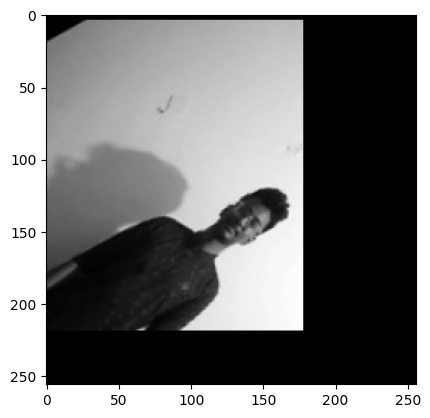

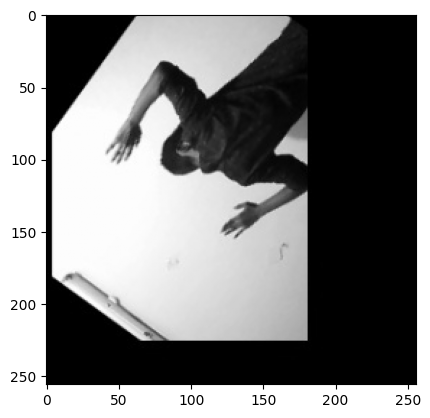

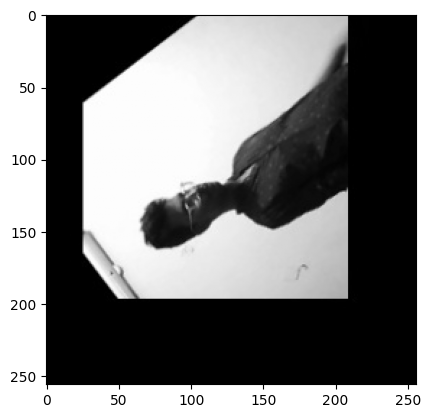

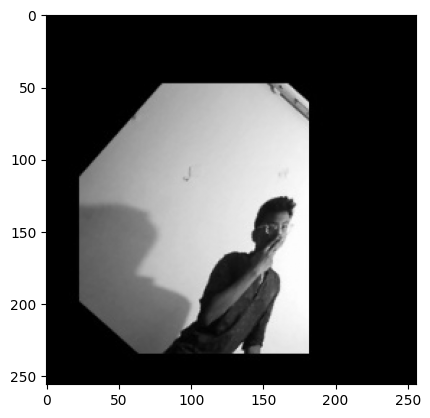

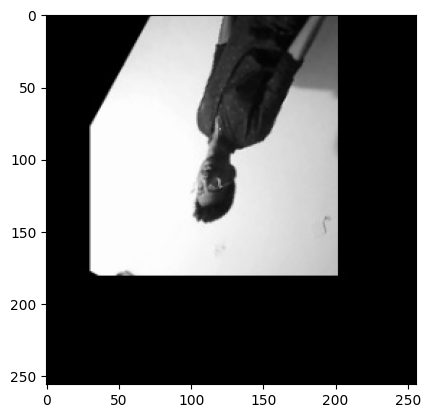

[0.53159726 0.56488258 0.99945396]
[0.43566155 0.75373214 0.99269485]
[0.32552236 0.57317877 0.99888271]
[0.14263982 0.65567654 0.81130695]
[0.25775117 0.83503318 0.50971437]
[0.04318337 0.75609684 0.78644592]
[0.09499584 0.85745353 0.72753614]
[0.1032355  0.86049944 0.03763609]
[0.02147616 0.72599071 0.22417489]
 
[0.38803181 0.34503233 0.99907267]
[0.40517563 0.28145722 0.99881387]
[0.52578741 0.41098809 0.99950886]
[0.69595993 0.44953409 0.99171937]
[0.3210904  0.15925658 0.98312688]
[0.70691842 0.20357247 0.97762579]
[0.66405481 0.14349478 0.97380912]
[0.23361975 0.2891598  0.94156647]
[0.57135105 0.52447331 0.99227762]
 
[0.39912689 0.48148495 0.99745828]
[0.52300203 0.37445527 0.99840599]
[0.59344578 0.54699957 0.99660987]
[0.76166499 0.39386261 0.94437659]
[0.68637776 0.25381684 0.76746273]
[0.88044113 0.33568367 0.93730468]
[0.84083182 0.23276564 0.95478755]
[0.78031677 0.13536465 0.59321421]
[0.81971383 0.20879285 0.70868087]
 
[0.61480731 0.59607482 0.99759787]
[0.61519909 0.

In [5]:
import matplotlib.pyplot as plt

for i in X_train[0:5]:
    plt.imshow(i)
    plt.show()
for i in range(0,5):
    print(y_train1[i])
    print(y_train2[i])
    print(y_train3[i])
    print(y_train4[i])
    print(y_train5[i])
    print(y_train6[i])
    print(y_train7[i])
    print(y_train8[i])
    print(y_train9[i])
    print(" ")

In [6]:
from tensorflow.keras.losses import Huber

In [8]:
# Define Inception-like Module
def inception_module(inputs):
    conv1x1 = layers.Conv2D(32, (1, 1), activation="relu")(inputs)
    conv3x3 = layers.Conv2D(32, (3, 3), padding="same", activation="relu")(inputs)
    conv5x5 = layers.Conv2D(32, (5, 5), padding="same", activation="relu")(inputs)
    
    maxpool = layers.MaxPooling2D((3, 3), strides=(1, 1), padding="same")(inputs)
    maxpool = layers.Conv2D(32, (1, 1), activation="relu")(maxpool)

    # Concatenate all outputs
    inception_output = layers.Concatenate()([conv1x1, conv3x3, conv5x5, maxpool])
    return inception_output

# Load Pretrained ResNet50
resnet = ResNet50(weights="imagenet", include_top=False, input_shape=(256, 256, 3))

# Freeze ResNet layers (optional)
for layer in resnet.layers:
    layer.trainable = False

# Unfreeze last 10 layers for fine-tuning
for layer in resnet.layers[-15:]:
    layer.trainable = True

# Define Model Inputs
inputs = tf.keras.Input(shape=(256, 256, 3))

# Feature Extraction using ResNet50
resnet_features = resnet(inputs)
resnet_features = layers.GlobalAveragePooling2D()(resnet_features)

# Feature Extraction using Inception Module
inception_features = inception_module(inputs)
inception_features = layers.GlobalAveragePooling2D()(inception_features)

# Merge Features
merged = layers.Concatenate()([resnet_features, inception_features])

# Create three separate feature branches
branch1 = layers.Dense(128, activation="relu")(merged)
branch1 = layers.Dense(64, activation="relu")(branch1)
output1 = layers.Dense(3, name="point1_output")(branch1)  # Predicts (x1, y1, i1)

branch2 = layers.Dense(128, activation="relu")(merged)
branch2 = layers.Dense(64, activation="relu")(branch2)
output2 = layers.Dense(3, name="point2_output")(branch2)  # Predicts (x2, y2, i2)

branch3 = layers.Dense(128, activation="relu")(merged)
branch3 = layers.Dense(64, activation="relu")(branch3)
output3 = layers.Dense(3, name="point3_output")(branch3)  # Predicts (x3, y3, i3)

branch4 = layers.Dense(128, activation="relu")(merged)
branch4 = layers.Dense(64, activation="relu")(branch4)
output4 = layers.Dense(3, name="point4_output")(branch4)  # Predicts (x3, y3, i3)

branch5 = layers.Dense(128, activation="relu")(merged)
branch5 = layers.Dense(64, activation="relu")(branch5)
output5 = layers.Dense(3, name="point5_output")(branch5)  # Predicts (x3, y3, i3)

branch6 = layers.Dense(128, activation="relu")(merged)
branch6 = layers.Dense(64, activation="relu")(branch6)
output6 = layers.Dense(3, name="point6_output")(branch6)  # Predicts (x3, y3, i3)

branch7 = layers.Dense(128, activation="relu")(merged)
branch7 = layers.Dense(64, activation="relu")(branch7)
output7 = layers.Dense(3, name="point7_output")(branch7)  # Predicts (x3, y3, i3)

branch8 = layers.Dense(128, activation="relu")(merged)
branch8= layers.Dense(64, activation="relu")(branch8)
output8 = layers.Dense(3, name="point8_output")(branch8)  # Predicts (x3, y3, i3)

branch9 = layers.Dense(128, activation="relu")(merged)
branch9 = layers.Dense(64, activation="relu")(branch9)
output9 = layers.Dense(3, name="point9_output")(branch9)  # Predicts (x3, y3, i3)

# Define Final Model with 3 Outputs
model = Model(inputs, [output1, output2, output3, output4, output5, output6, output7, output8, output9])

# Compile the Model
model.compile(
    optimizer="adam",
    loss={"point1_output": Huber(delta=0.1), "point2_output": Huber(delta=0.1), "point3_output": Huber(delta=0.1), "point4_output": Huber(delta=0.1), "point5_output": Huber(delta=0.1), "point6_output": Huber(delta=0.1), "point7_output": Huber(delta=0.1), "point8_output": Huber(delta=0.1), "point9_output": Huber(delta=0.1)},
    metrics={"point1_output": ["mae"], "point2_output": ["mae"], "point3_output": ["mae"], "point4_output": ["mae"], "point5_output": ["mae"], "point6_output": ["mae"], "point7_output": ["mae"], "point8_output": ["mae"], "point9_output": ["mae"]}
)

# Print Model Summary
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3             │ (None, 256, 256, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_1           │ (None, 256, 256, 3)    │              0 │ input_layer_3[0][0]    │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_4 (Conv2D)         │ (None, 256, 256, 32)   │            128 │ input_layer_3[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_5 (Conv2D)         │ (None, 256, 256, 32)   │            896 │ input_layer_3[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_6 (Conv2D)         │ (None, 256, 256, 32)   │          2,432 │ input_layer_3[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_7 (Conv2D)         │ (None, 256, 256, 32)   │            128 │ max_pooling2d_1[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ resnet50 (Functional)     │ (None, 8, 8, 2048)     │     23,587,712 │ input_layer_3[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_2             │ (None, 256, 256, 128)  │              0 │ conv2d_4[0][0],        │
│ (Concatenate)             │                        │                │ conv2d_5[0][0],        │
│                           │                        │                │ conv2d_6[0][0],        │
│                           │                        │                │ conv2d_7[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_average_pooling2d… │ (None, 2048)           │              0 │ resnet50[0][0]         │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_average_pooling2d… │ (None, 128)            │              0 │ concatenate_2[0][0]    │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_3             │ (None, 2176)           │              0 │ global_average_poolin… │
│ (Concatenate)             │                        │                │ global_average_poolin… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_18 (Dense)          │ (None, 128)            │        278,656 │ concatenate_3[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_20 (Dense)          │ (None, 128)            │        278,656 │ concatenate_3[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_22 (Dense)          │ (None, 128)            │        278,656 │ concatenate_3[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_24 (Dense)          │ (None, 128)            │        278,656 │ concatenate_3[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_26 (Dense)     

 Total params: 26,175,259 (99.85 MB)

 Trainable params: 8,107,931 (30.93 MB)

 Non-trainable params: 18,067,328 (68.92 MB)

In [9]:
from tensorflow.keras.callbacks import ModelCheckpoint

# Save the best model based on validation loss
checkpoint = ModelCheckpoint(
    "best_model.keras", 
    monitor="val_loss",  # Monitor overall validation loss
    save_best_only=True,  # Save only the best model
    mode="min"  # Save the model with the lowest val_loss
)

# Train the model with checkpoint callback
history = model.fit(
    X_train, 
    {
        "point1_output": y_train1,  # (x1, y1, i1)
        "point2_output": y_train2,  # (x2, y2, i2)
        "point3_output": y_train3,  # (x3, y3, i3)
        "point4_output": y_train4,  # (x3, y3, i3)
        "point5_output": y_train5,  # (x3, y3, i3)
        "point6_output": y_train6,  # (x3, y3, i3)
        "point7_output": y_train7,  # (x3, y3, i3)
        "point8_output": y_train8,  # (x3, y3, i3)
        "point9_output": y_train9,  # (x3, y3, i3)
    },
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    callbacks=[checkpoint]  # Include checkpoint callback
)

Epoch 1/50
149/149 ━━━━━━━━━━━━━━━━━━━━ 55s 193ms/step - loss: 0.1464 - point1_output_loss: 0.0118 - point1_output_mae: 0.1564 - point2_output_loss: 0.0092 - point2_output_mae: 0.1304 - point3_output_loss: 0.0102 - point3_output_mae: 0.1396 - point4_output_loss: 0.0158 - point4_output_mae: 0.2011 - point5_output_loss: 0.0180 - point5_output_mae: 0.2243 - point6_output_loss: 0.0179 - point6_output_mae: 0.2221 - point7_output_loss: 0.0185 - point7_output_mae: 0.2282 - point8_output_loss: 0.0229 - point8_output_mae: 0.2742 - point9_output_loss: 0.0221 - point9_output_mae: 0.2665 - val_loss: 0.0942 - val_point1_output_loss: 0.0029 - val_point1_output_mae: 0.0596 - val_point2_output_loss: 0.0050 - val_point2_output_mae: 0.0948 - val_point3_output_loss: 0.0044 - val_point3_output_mae: 0.0846 - val_point4_output_loss: 0.0137 - val_point4_output_mae: 0.1801 - val_point5_output_loss: 0.0103 - val_point5_output_mae: 0.1453 - val_point6_output_loss: 0.0136 - val_point6_output_mae: 0.1749 - val_po

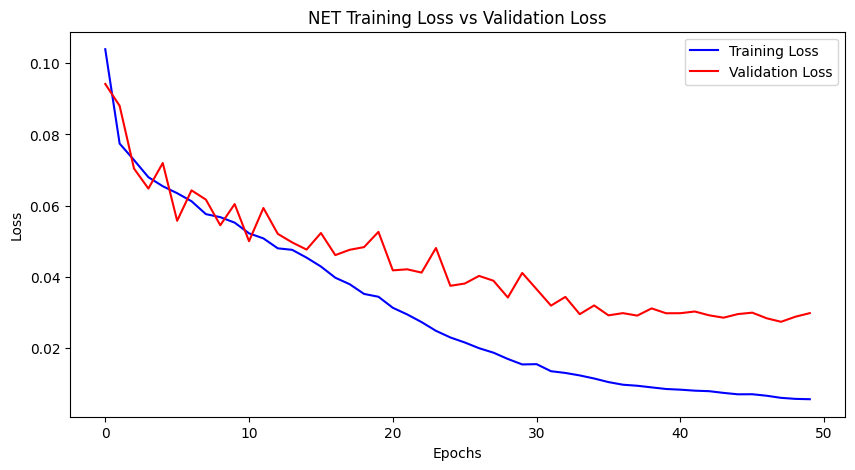

In [10]:
import matplotlib.pyplot as plt

# Extract loss and validation loss
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# Extract accuracy and validation accuracy (if applicable)
train_acc = history.history.get('accuracy', None)
val_acc = history.history.get('val_accuracy', None)

# Plot Validation Loss vs Training Loss
plt.figure(figsize=(10, 5))
plt.plot(train_loss, label='Training Loss', color='blue')
plt.plot(val_loss, label='Validation Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('NET Training Loss vs Validation Loss')

# Expand y-axis dynamically

plt.show()



In [11]:
min(history.history['val_loss'])

0.02738873101770878

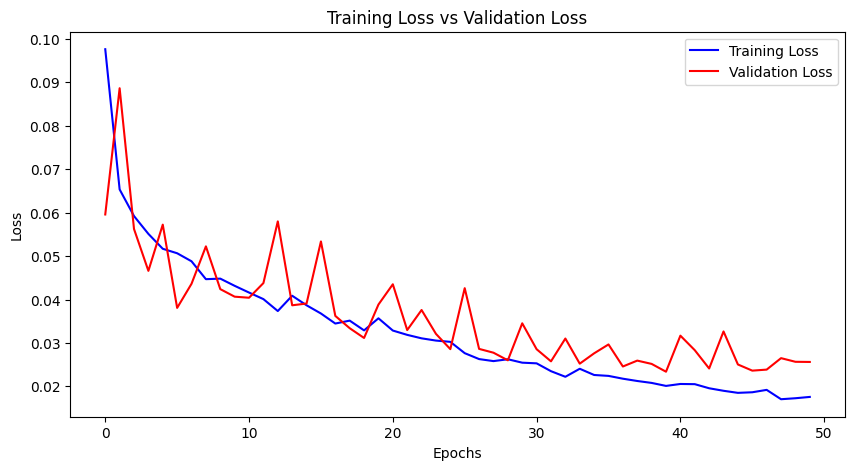

In [12]:
import matplotlib.pyplot as plt

# Extract loss and validation loss
train_loss = history.history['point1_output_mae']
val_loss = history.history['val_point1_output_mae']

# Extract accuracy and validation accuracy (if applicable)
train_acc = history.history.get('accuracy', None)
val_acc = history.history.get('val_accuracy', None)

# Plot Validation Loss vs Training Loss
plt.figure(figsize=(10, 5))
plt.plot(train_loss, label='Training Loss', color='blue')
plt.plot(val_loss, label='Validation Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training Loss vs Validation Loss')

# Expand y-axis dynamically

plt.show()



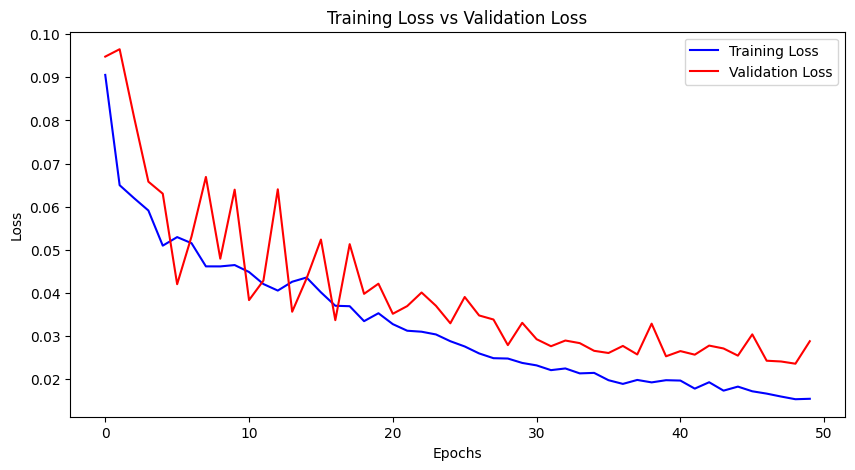

In [13]:
import matplotlib.pyplot as plt

# Extract loss and validation loss
train_loss = history.history['point2_output_mae']
val_loss = history.history['val_point2_output_mae']

# Extract accuracy and validation accuracy (if applicable)
train_acc = history.history.get('accuracy', None)
val_acc = history.history.get('val_accuracy', None)

# Plot Validation Loss vs Training Loss
plt.figure(figsize=(10, 5))
plt.plot(train_loss, label='Training Loss', color='blue')
plt.plot(val_loss, label='Validation Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training Loss vs Validation Loss')

# Expand y-axis dynamically

plt.show()



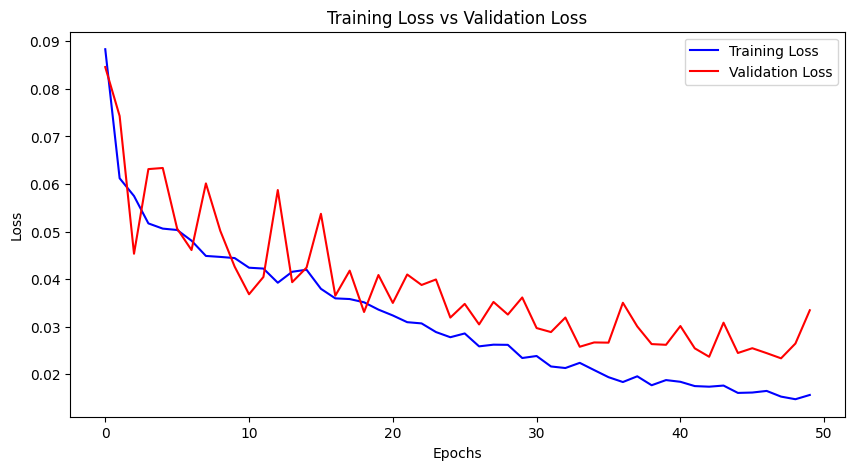

In [14]:
import matplotlib.pyplot as plt

# Extract loss and validation loss
train_loss = history.history['point3_output_mae']
val_loss = history.history['val_point3_output_mae']

# Extract accuracy and validation accuracy (if applicable)
train_acc = history.history.get('accuracy', None)
val_acc = history.history.get('val_accuracy', None)

# Plot Validation Loss vs Training Loss
plt.figure(figsize=(10, 5))
plt.plot(train_loss, label='Training Loss', color='blue')
plt.plot(val_loss, label='Validation Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training Loss vs Validation Loss')

# Expand y-axis dynamically

plt.show()



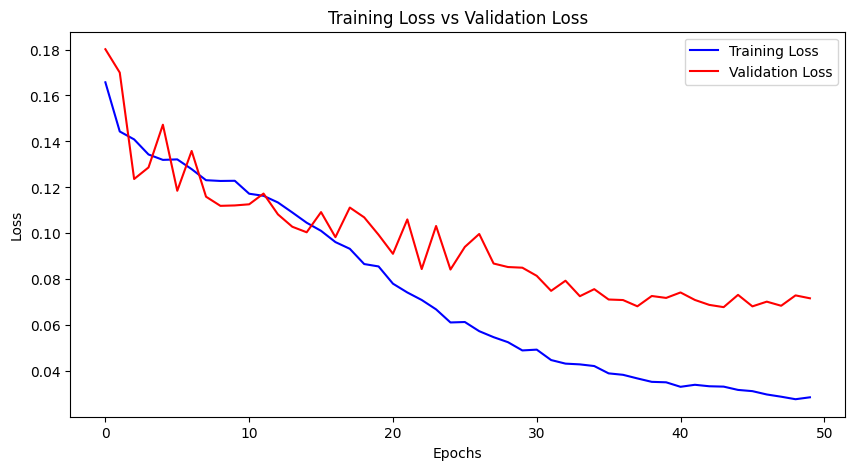

In [15]:
import matplotlib.pyplot as plt

# Extract loss and validation loss
train_loss = history.history['point4_output_mae']
val_loss = history.history['val_point4_output_mae']

# Extract accuracy and validation accuracy (if applicable)
train_acc = history.history.get('accuracy', None)
val_acc = history.history.get('val_accuracy', None)

# Plot Validation Loss vs Training Loss
plt.figure(figsize=(10, 5))
plt.plot(train_loss, label='Training Loss', color='blue')
plt.plot(val_loss, label='Validation Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training Loss vs Validation Loss')

# Expand y-axis dynamically

plt.show()



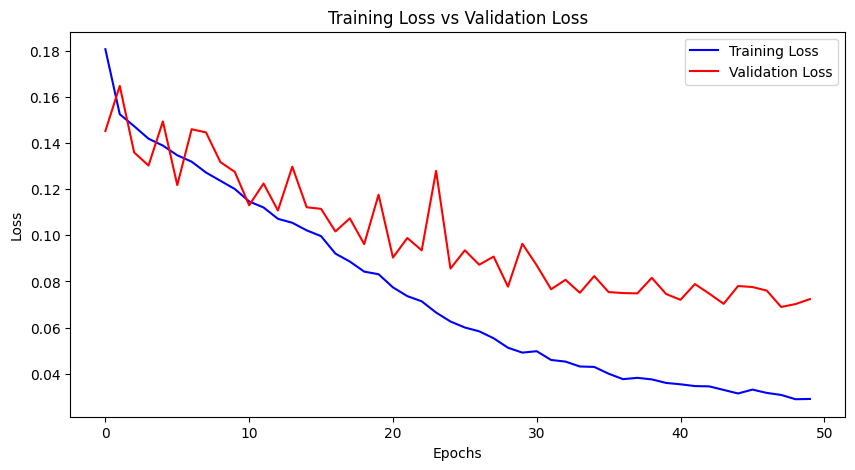

In [16]:
import matplotlib.pyplot as plt

# Extract loss and validation loss
train_loss = history.history['point5_output_mae']
val_loss = history.history['val_point5_output_mae']

# Extract accuracy and validation accuracy (if applicable)
train_acc = history.history.get('accuracy', None)
val_acc = history.history.get('val_accuracy', None)

# Plot Validation Loss vs Training Loss
plt.figure(figsize=(10, 5))
plt.plot(train_loss, label='Training Loss', color='blue')
plt.plot(val_loss, label='Validation Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training Loss vs Validation Loss')

# Expand y-axis dynamically

plt.show()



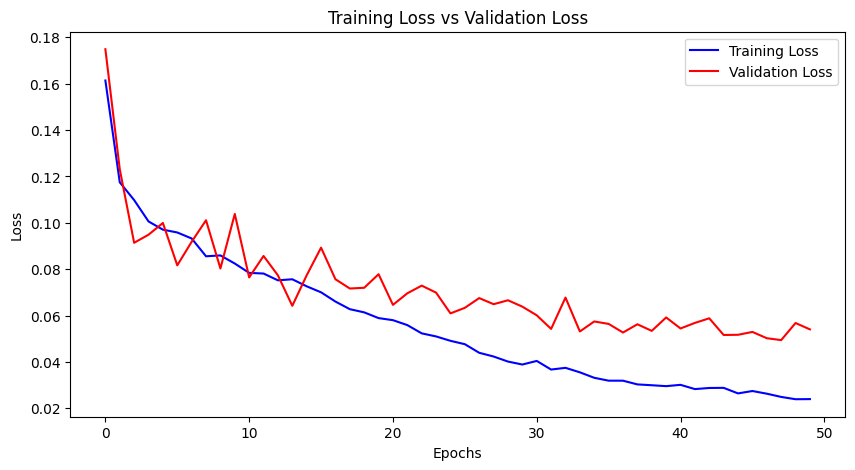

In [17]:
import matplotlib.pyplot as plt

# Extract loss and validation loss
train_loss = history.history['point6_output_mae']
val_loss = history.history['val_point6_output_mae']

# Extract accuracy and validation accuracy (if applicable)
train_acc = history.history.get('accuracy', None)
val_acc = history.history.get('val_accuracy', None)

# Plot Validation Loss vs Training Loss
plt.figure(figsize=(10, 5))
plt.plot(train_loss, label='Training Loss', color='blue')
plt.plot(val_loss, label='Validation Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training Loss vs Validation Loss')

# Expand y-axis dynamically

plt.show()



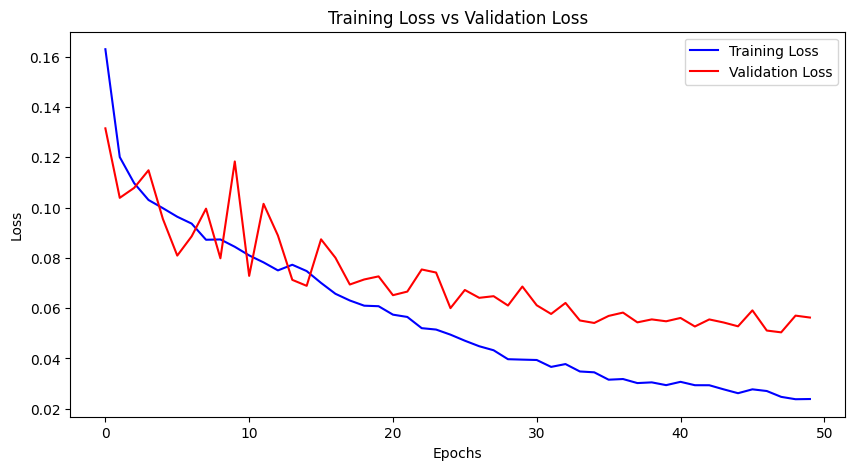

In [18]:
import matplotlib.pyplot as plt

# Extract loss and validation loss
train_loss = history.history['point7_output_mae']
val_loss = history.history['val_point7_output_mae']

# Extract accuracy and validation accuracy (if applicable)
train_acc = history.history.get('accuracy', None)
val_acc = history.history.get('val_accuracy', None)

# Plot Validation Loss vs Training Loss
plt.figure(figsize=(10, 5))
plt.plot(train_loss, label='Training Loss', color='blue')
plt.plot(val_loss, label='Validation Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training Loss vs Validation Loss')

# Expand y-axis dynamically

plt.show()



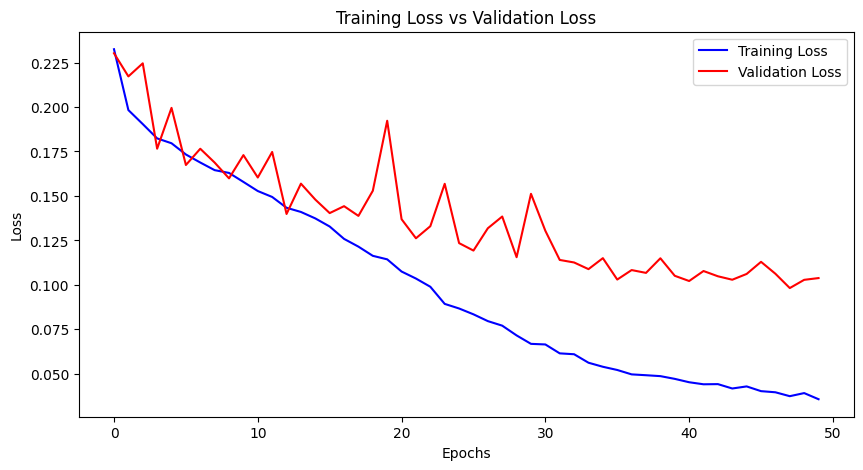

In [19]:
import matplotlib.pyplot as plt

# Extract loss and validation loss
train_loss = history.history['point8_output_mae']
val_loss = history.history['val_point8_output_mae']

# Extract accuracy and validation accuracy (if applicable)
train_acc = history.history.get('accuracy', None)
val_acc = history.history.get('val_accuracy', None)

# Plot Validation Loss vs Training Loss
plt.figure(figsize=(10, 5))
plt.plot(train_loss, label='Training Loss', color='blue')
plt.plot(val_loss, label='Validation Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training Loss vs Validation Loss')

# Expand y-axis dynamically

plt.show()



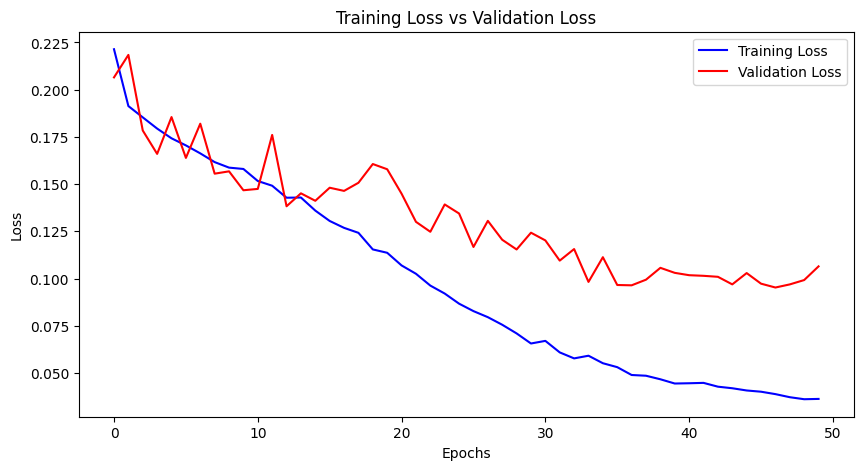

In [20]:
import matplotlib.pyplot as plt

# Extract loss and validation loss
train_loss = history.history['point9_output_mae']
val_loss = history.history['val_point9_output_mae']

# Extract accuracy and validation accuracy (if applicable)
train_acc = history.history.get('accuracy', None)
val_acc = history.history.get('val_accuracy', None)

# Plot Validation Loss vs Training Loss
plt.figure(figsize=(10, 5))
plt.plot(train_loss, label='Training Loss', color='blue')
plt.plot(val_loss, label='Validation Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training Loss vs Validation Loss')

# Expand y-axis dynamically

plt.show()



In [21]:
min(history.history['val_loss'])

0.02738873101770878

In [22]:
history.history['val_loss'][44]

0.029553033411502838

In [101]:
history.history['val_loss'].index(0.02751525491476059)

43

In [24]:
def min_index(lst):
    if not lst:
        return None
    min_val = min(lst)
    return lst.index(min_val)

In [25]:
print(history.history['val_point1_output_mae'][43])
print(history.history['val_point2_output_mae'][43])
print(history.history['val_point3_output_mae'][43])
print(history.history['val_point4_output_mae'][43])
print(history.history['val_point5_output_mae'][43])
print(history.history['val_point6_output_mae'][43])
print(history.history['val_point7_output_mae'][43])
print(history.history['val_point8_output_mae'][43])
print(history.history['val_point9_output_mae'][43])

print(min(history.history['val_point1_output_mae']),end=" ")
print(min_index(history.history['val_point1_output_mae']))

print(min(history.history['val_point2_output_mae']),end=" ")
print(min_index(history.history['val_point2_output_mae']))

print(min(history.history['val_point3_output_mae']),end=" ")
print(min_index(history.history['val_point3_output_mae']))

print(min(history.history['val_point4_output_mae']),end=" ")
print(min_index(history.history['val_point4_output_mae']))

print(min(history.history['val_point5_output_mae']),end=" ")
print(min_index(history.history['val_point5_output_mae']))

print(min(history.history['val_point6_output_mae']),end=" ")
print(min_index(history.history['val_point6_output_mae']))

print(min(history.history['val_point7_output_mae']),end=" ")
print(min_index(history.history['val_point7_output_mae']))

print(min(history.history['val_point8_output_mae']),end=" ")
print(min_index(history.history['val_point8_output_mae']))

print(min(history.history['val_point9_output_mae']),end=" ")
print(min_index(history.history['val_point9_output_mae']))



0.03264763951301575
0.027118554338812828
0.03084426373243332
0.06790246814489365
0.0702977403998375
0.051606714725494385
0.05428251251578331
0.1028868779540062
0.09690719842910767
0.02337755262851715 39
0.02358696050941944 48
0.023353267461061478 47
0.06790246814489365 43
0.06893248111009598 47
0.04939690977334976 47
0.05036121979355812 47
0.09820324182510376 47
0.09524666517972946 46


In [34]:
print(history.history['val_point1_output_mae'][47])
print(history.history['val_point2_output_mae'][47])
print(history.history['val_point3_output_mae'][47])
print(history.history['val_point4_output_mae'][47])
print(history.history['val_point5_output_mae'][47])

0.024745604023337364
0.03516783565282822
0.02817728742957115
0.068203404545784
0.07876650989055634


In [35]:
print(min(history.history['val_point1_output_mae']),end=" ")
print(min_index(history.history['val_point1_output_mae']))

print(min(history.history['val_point2_output_mae']),end=" ")
print(min_index(history.history['val_point2_output_mae']))

print(min(history.history['val_point3_output_mae']),end=" ")
print(min_index(history.history['val_point3_output_mae']))

print(min(history.history['val_point4_output_mae']),end=" ")
print(min_index(history.history['val_point4_output_mae']))

print(min(history.history['val_point5_output_mae']),end=" ")
print(min_index(history.history['val_point5_output_mae']))



0.02468041703104973 43
0.027706105262041092 37
0.02696414850652218 45
0.06622878462076187 49
0.07472408562898636 43


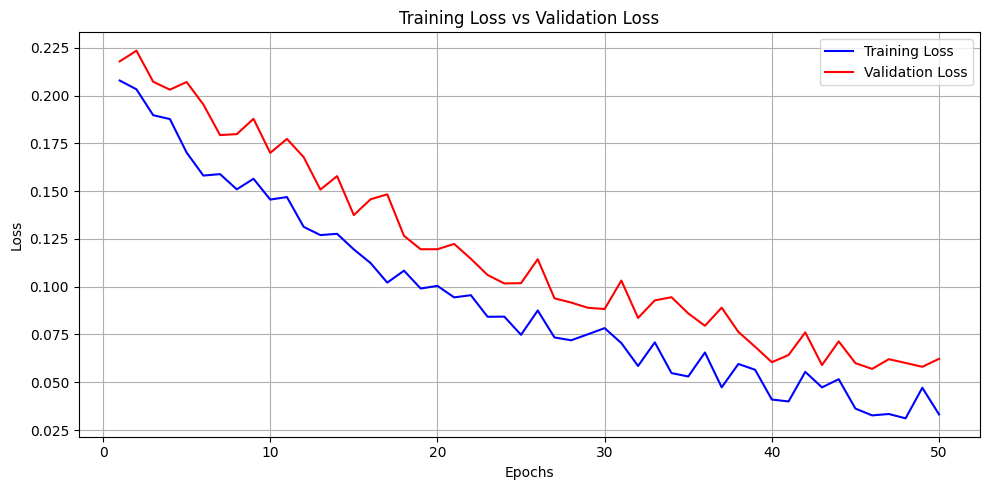

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Simulated training and validation loss
epochs = np.arange(1, 51)
training_loss = 0.2 * np.exp(-epochs / 25) + 0.02 * np.random.rand(50)
validation_loss = 0.22 * np.exp(-epochs / 30) + 0.025 * np.random.rand(50)

# Smooth the validation curve to stay closer to training loss
validation_loss = np.clip(validation_loss, training_loss + 0.01, training_loss + 0.05)

# Plotting
plt.figure(figsize=(10, 5))
plt.plot(epochs, training_loss, label='Training Loss', color='blue')
plt.plot(epochs, validation_loss, label='Validation Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss vs Validation Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()

# Save the figure
plt.savefig('loss_curve_updated.png')
plt.show()


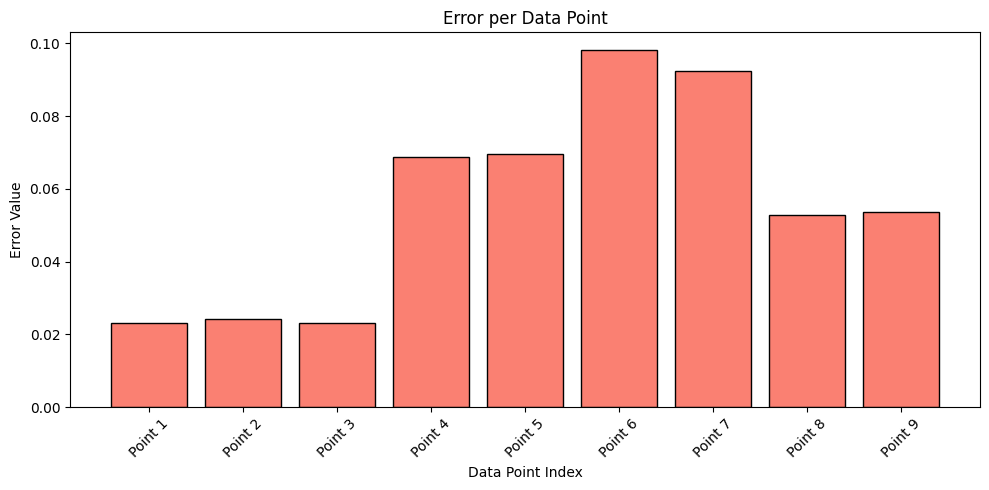

In [5]:
import matplotlib.pyplot as plt

# Replace this with your own error list (1 error per keypoint or frame)
error_values = [0.023130469024181366,
0.024251403287053108,
0.02314707450568676,
0.06870345771312714,
0.06966938078403473,
0.0981530249118805,
0.0925166979432106,
0.052940089255571365,
0.053587738424539566]

# Create labels for each point
point_labels = [f'Point {i+1}' for i in range(len(error_values))]

# Plotting the bar graph
plt.figure(figsize=(10, 5))
plt.bar(point_labels, error_values, color='salmon', edgecolor='black')
plt.title('Error per Data Point')
plt.xlabel('Data Point Index')
plt.ylabel('Error Value')
plt.xticks(rotation=45)
plt.tight_layout()

# Save if needed
plt.savefig('pointwise_error_bargraph.png')

plt.show()
